<a href="https://colab.research.google.com/github/LucaGandolfi77/qiskit/blob/develop/new/unpr03_v24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit-optimization
!pip install networkx
!pip install matplotlib
!pip install numpy
!pip install seaborn
!pip install pyvis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.4/643.4 kB 17.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.6/167.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 5.9 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.28.240-py3-none-any.whl size=682834 sha256=2c8e7847102f829a

In [2]:
import matplotlib.pyplot as plt

from docplex.mp.model import Model

from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Sampler
from qiskit_optimization.algorithms import CobylaOptimizer, MinimumEigenOptimizer
from qiskit_optimization.algorithms.admm_optimizer import ADMMParameters, ADMMOptimizer
from qiskit_optimization.translators import from_docplex_mp

# If CPLEX is installed, you can uncomment this line to import the CplexOptimizer.
# CPLEX can be used in this tutorial to solve the convex continuous problem,
# but also as a reference to solve the QUBO, or even the full problem.
#
# from qiskit.optimization.algorithms import CplexOptimizer

In [3]:
# define COBYLA optimizer to handle convex continuous problems.
cobyla = CobylaOptimizer()

# define QAOA via the minimum eigen optimizer
qaoa = MinimumEigenOptimizer(QAOA(sampler=Sampler(), optimizer=COBYLA()))

# exact QUBO solver as classical benchmark
exact = MinimumEigenOptimizer(NumPyMinimumEigensolver())  # to solve QUBOs

# in case CPLEX is installed it can also be used for the convex problems, the QUBO,
# or as a benchmark for the full problem.
#
# cplex = CplexOptimizer()

<ipython-input-3-fbfdec1de0d7>:5: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  qaoa = MinimumEigenOptimizer(QAOA(sampler=Sampler(), optimizer=COBYLA()))


In [4]:
# construct model using docplex
mdl = Model("ex119")

#server = M = 4 = i = i0, i1, i2, i3
#virtual machine = N = 4 = j = j0, j1, j2, j3
#all servers have the same idle and dynamic power consumption
#all servers have the same maximum cpu capacity

si0 = mdl.binary_var(name="si0")
si1 = mdl.binary_var(name="si1")
si2 = mdl.binary_var(name="si2")
si3 = mdl.binary_var(name="si3")
si4 = mdl.binary_var(name="si4")

vj0i0 = mdl.continuous_var(name="vj0i0")
vj1i0 = mdl.continuous_var(name="vj1i0")
vj2i0 = mdl.continuous_var(name="vj2i0")
vj3i0 = mdl.continuous_var(name="vj3i0")
vj4i0 = mdl.continuous_var(name="vj4i0")

vj0i1 = mdl.continuous_var(name="vj0i1")
vj1i1 = mdl.continuous_var(name="vj1i1")
vj2i1 = mdl.continuous_var(name="vj2i1")
vj3i1 = mdl.continuous_var(name="vj3i1")
vj4i1 = mdl.continuous_var(name="vj4i1")

vj0i2 = mdl.continuous_var(name="vj0i2")
vj1i2 = mdl.continuous_var(name="vj1i2")
vj2i2 = mdl.continuous_var(name="vj2i2")
vj3i2 = mdl.continuous_var(name="vj3i2")
vj4i2 = mdl.continuous_var(name="vj4i2")

vj0i3 = mdl.continuous_var(name="vj0i3")
vj1i3 = mdl.continuous_var(name="vj1i3")
vj2i3 = mdl.continuous_var(name="vj2i3")
vj3i3 = mdl.continuous_var(name="vj3i3")
vj4i3 = mdl.continuous_var(name="vj4i3")

vj0i4 = mdl.continuous_var(name="vj0i4")
vj1i4 = mdl.continuous_var(name="vj1i4")
vj2i4 = mdl.continuous_var(name="vj2i4")
vj3i4 = mdl.continuous_var(name="vj3i4")
vj4i4 = mdl.continuous_var(name="vj4i4")

pi = 1
pd = 1
pi0 = 1
pd0 = 1
pi1 = 1
pd1 = 1
pi2 = 1
pd2 = 1
pi3 = 1
pd3 = 1
pi4 = 1
pd4 = 1
ci0 = 11
ci1 = 11
ci2 = 11
ci3 = 10
ci4 = 10

uj0 = mdl.continuous_var(name="uj0")
uj1 = mdl.continuous_var(name="uj1")
uj2 = mdl.continuous_var(name="uj2")
uj3 = mdl.continuous_var(name="uj3")
uj4 = mdl.continuous_var(name="uj4")

sum0 = (vj0i0+vj1i0+vj2i0+vj3i0+vj4i0)
sum1 = (vj0i1+vj1i1+vj2i1+vj3i1+vj4i1)
sum2 = (vj0i2+vj1i2+vj2i2+vj3i2+vj4i2)
sum3 = (vj0i3+vj1i3+vj2i3+vj3i3+vj4i3)
sum4 = (vj0i4+vj1i4+vj2i4+vj3i4+vj4i4)

mdl.minimize(pi0*si0+pd0*(uj0*vj0i0+uj1*vj1i0+uj2*vj2i0+uj3*vj3i0+uj4*vj4i0)+pi1*si1+pd1*(uj0*vj0i1+uj1*vj1i1+uj2*vj2i1+uj3*vj3i1+uj4*vj4i1)+pi2*si2+pd2*(uj0*vj0i2+uj1*vj1i2+uj2*vj2i2+uj3*vj3i2+uj4*vj4i2)+pi3*si3+pd3*(uj0*vj0i3+uj1*vj1i3+uj2*vj2i3+uj3*vj3i3+uj4*vj4i3)+pi4*si4+pd4*(uj0*vj0i4+uj1*vj1i4+uj2*vj2i4+uj3*vj3i4+uj4*vj4i4))

mdl.add_constraint((vj0i0+vj1i0+vj2i0+vj3i0+vj4i0) >= ci0-1, "cons2")
mdl.add_constraint((vj0i1+vj1i1+vj2i1+vj3i1+vj4i1) >= ci1-1, "cons3")
mdl.add_constraint((vj0i2+vj1i2+vj2i2+vj3i2+vj4i2) >= ci2-1, "cons4")
mdl.add_constraint((vj0i3+vj1i3+vj2i3+vj3i3+vj4i3) >= ci3-1, "cons5")
mdl.add_constraint((vj0i4+vj1i4+vj2i4+vj3i4+vj4i4) >= ci4-1, "cons5a")

mdl.add_constraint((vj0i0+vj1i0+vj2i0+vj3i0+vj4i0) >= 0, "cons6")
mdl.add_constraint((vj0i1+vj1i1+vj2i1+vj3i1+vj4i1) >= 0, "cons7")
mdl.add_constraint((vj0i2+vj1i2+vj2i2+vj3i2+vj4i2) >= 0, "cons8")
mdl.add_constraint((vj0i3+vj1i3+vj2i3+vj3i3+vj4i3) >= 0, "cons9")
mdl.add_constraint((vj0i4+vj1i4+vj2i4+vj3i4+vj4i4) >= 0, "cons9a")

#mdl.add_constraint((vj0i0+vj1i0+vj2i0) <= ci0,"cons10")
#mdl.add_constraint((vj0i1+vj1i1+vj2i1) <= ci1, "cons11")
#mdl.add_constraint((vj0i2+vj1i2+vj2i2) <= ci2, "cons12")

mdl.add_constraint((si0) >= 1, "cons14")
mdl.add_constraint((si1) >= 1, "cons15")
mdl.add_constraint((si2) >= 1, "cons16")
mdl.add_constraint((si3) >= 1, "cons17")
mdl.add_constraint((si4) >= 1, "cons17a")

mdl.add_constraint((vj0i0+vj0i1+vj0i2+vj0i3+vj0i4) <= 11,"cons18")
mdl.add_constraint((vj1i0+vj1i1+vj1i2+vj1i3+vj1i4) <= 11,"cons19")
mdl.add_constraint((vj2i0+vj2i1+vj2i2+vj2i3+vj2i4) <= 11,"cons20")
mdl.add_constraint((vj3i0+vj3i1+vj3i2+vj3i3+vj3i4) <= 10,"cons21")
mdl.add_constraint((vj4i0+vj4i1+vj4i2+vj4i3+vj4i4) <= 10,"cons21a")

mdl.add_constraint(uj0 >= 1,"cons22")
mdl.add_constraint(uj1 >= 1,"cons23")
mdl.add_constraint(uj2 >= 1,"cons24")
mdl.add_constraint(uj3 >= 1,"cons25")
mdl.add_constraint(uj4 >= 1,"cons25a")

docplex.mp.LinearConstraint[cons25a](uj4,GE,1)

In [5]:
# construct model using docplex
#mdl = Model("ex6")
#
#v = mdl.binary_var(name="v")
#w = mdl.binary_var(name="w")
#t = mdl.binary_var(name="t")
#u = mdl.continuous_var(name="u")
#
#mdl.minimize(v + w + t + 5 * (u - 2) ** 2)
#mdl.add_constraint(v + 2 * w + t + u <= 3, "cons1")
#mdl.add_constraint(v + w + t >= 1, "cons2")
#mdl.add_constraint(v + w == 1, "cons3")

# load quadratic program from docplex model
qp = from_docplex_mp(mdl)
print(qp.prettyprint())

Problem name: ex119

Minimize
  vj0i0*uj0 + vj0i1*uj0 + vj0i2*uj0 + vj0i3*uj0 + vj0i4*uj0 + vj1i0*uj1
  + vj1i1*uj1 + vj1i2*uj1 + vj1i3*uj1 + vj1i4*uj1 + vj2i0*uj2 + vj2i1*uj2
  + vj2i2*uj2 + vj2i3*uj2 + vj2i4*uj2 + vj3i0*uj3 + vj3i1*uj3 + vj3i2*uj3
  + vj3i3*uj3 + vj3i4*uj3 + vj4i0*uj4 + vj4i1*uj4 + vj4i2*uj4 + vj4i3*uj4
  + vj4i4*uj4 + si0 + si1 + si2 + si3 + si4

Subject to
  Linear constraints (25)
    vj0i0 + vj1i0 + vj2i0 + vj3i0 + vj4i0 >= 10  'cons2'
    vj0i1 + vj1i1 + vj2i1 + vj3i1 + vj4i1 >= 10  'cons3'
    vj0i2 + vj1i2 + vj2i2 + vj3i2 + vj4i2 >= 10  'cons4'
    vj0i3 + vj1i3 + vj2i3 + vj3i3 + vj4i3 >= 9  'cons5'
    vj0i4 + vj1i4 + vj2i4 + vj3i4 + vj4i4 >= 9  'cons5a'
    vj0i0 + vj1i0 + vj2i0 + vj3i0 + vj4i0 >= 0  'cons6'
    vj0i1 + vj1i1 + vj2i1 + vj3i1 + vj4i1 >= 0  'cons7'
    vj0i2 + vj1i2 + vj2i2 + vj3i2 + vj4i2 >= 0  'cons8'
    vj0i3 + vj1i3 + vj2i3 + vj3i3 + vj4i3 >= 0  'cons9'
    vj0i4 + vj1i4 + vj2i4 + vj3i4 + vj4i4 >= 0  'cons9a'
    si0 >= 1  'cons14'
    si

In [6]:
admm_params = ADMMParameters(
    rho_initial=1001, beta=1000, factor_c=900, maxiter=100, three_block=True, tol=1.0e-6
)

In [7]:
# define QUBO optimizer
qubo_optimizer = exact
# qubo_optimizer = cplex  # uncomment to use CPLEX instead

# define classical optimizer
convex_optimizer = cobyla
# convex_optimizer = cplex  # uncomment to use CPLEX instead

# initialize ADMM with classical QUBO and convex optimizer
admm = ADMMOptimizer(
    params=admm_params, qubo_optimizer=qubo_optimizer, continuous_optimizer=convex_optimizer
)

In [8]:
# run ADMM to solve problem
result = admm.solve(qp)

In [9]:
# define QUBO optimizer
qubo_optimizer = qaoa

# define classical optimizer
convex_optimizer = cobyla
# convex_optimizer = cplex  # uncomment to use CPLEX instead

# initialize ADMM with quantum QUBO optimizer and classical convex optimizer
admm_q = ADMMOptimizer(
    params=admm_params, qubo_optimizer=qubo_optimizer, continuous_optimizer=convex_optimizer
)

In [10]:
# run ADMM to solve problem
result_q = admm_q.solve(qp)

In [11]:
print(result.prettyprint())

objective function value: 53.00000000000002
variable values: si0=1.0, si1=1.0, si2=1.0, si3=1.0, si4=1.0, vj0i0=1.9827777330968432, vj1i0=1.9897442136334689, vj2i0=2.017476391208573, vj3i0=2.0040294763425734, vj4i0=2.005972185718553, vj0i1=1.982607873551778, vj1i1=1.990965819329416, vj2i1=1.9983625923272108, vj3i1=2.0239938891599634, vj4i1=2.004069825631642, vj0i2=2.0091169756586695, vj1i2=1.99598993062777, vj2i2=1.9971876105467088, vj3i2=1.9939588417927077, vj4i2=2.0037466413741454, vj0i3=1.8000402823321626, vj1i3=1.7872979425258742, vj2i3=1.8028813473968637, vj3i3=1.8083547350153004, vj4i3=1.8014256927298002, vj0i4=1.799004242686777, vj1i4=1.7979513375773175, vj2i4=1.8112800862350538, vj3i4=1.8056331609345044, vj4i4=1.7861311725663467, uj0=1.0, uj1=1.0, uj2=1.0, uj3=1.0, uj4=1.0
status: SUCCESS


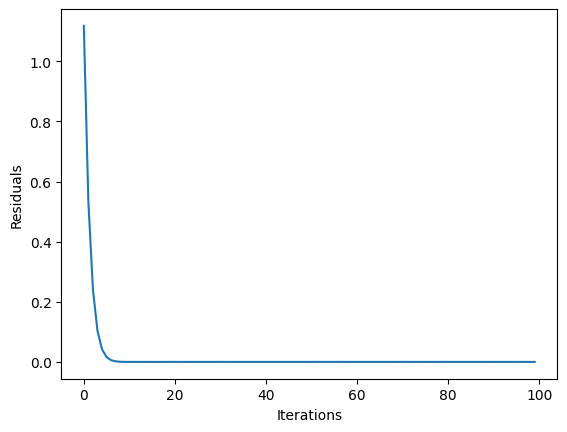

In [13]:
plt.clf()
plt.plot(result_q.state.residuals)
plt.xlabel("Iterations")
plt.ylabel("Residuals")
plt.show()

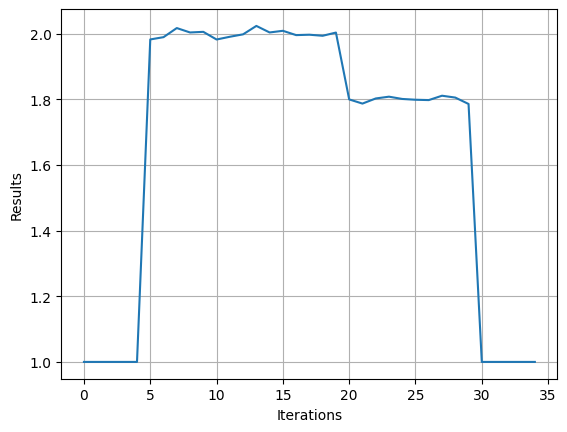

In [14]:
plt.plot(result.x)
plt.xlabel("Iterations")
plt.ylabel("Results")
plt.grid()
plt.show()

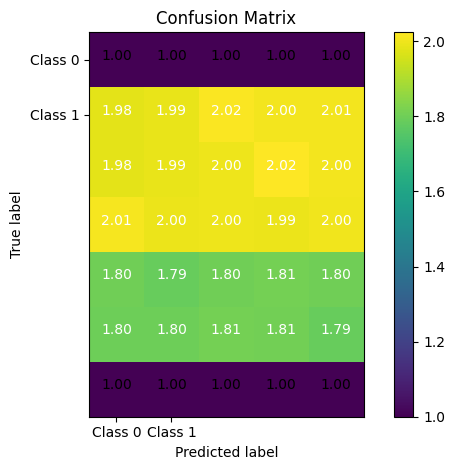

In [20]:
# prompt: print result.x as a confusion matrix

import matplotlib.pyplot as plt
import numpy as np

# Assuming result.x is a 1D array or list
try:
  # Convert result.x to a NumPy array if it isn't already
  x_values = np.array(result.x)

  # Assuming you have the correct dimensions for a confusion matrix
  # (e.g., result.x has 4 elements, you can reshape it into 6x6)
  confusion_matrix = x_values.reshape(7, 5)

  plt.imshow(confusion_matrix, cmap='viridis', interpolation='nearest')
  plt.title('Confusion Matrix')
  plt.colorbar()
  tick_marks = np.arange(2)
  plt.xticks(tick_marks, ['Class 0', 'Class 1'])
  plt.yticks(tick_marks, ['Class 0', 'Class 1'])

  thresh = confusion_matrix.max() / 2.
  for i in range(confusion_matrix.shape[0]):
      for j in range(confusion_matrix.shape[1]):
          plt.text(j, i, format(confusion_matrix[i, j], '0.2f'),
                   horizontalalignment="center",
                   color="white" if confusion_matrix[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()
  plt.show()
except Exception as e:
  print(f"Error: Couldn't create confusion matrix from result.x: {e}")
  print("Make sure result.x is a suitable array for a confusion matrix.")